# 02 — Análisis Univariado

## Modelación Predictiva de la Siniestralidad en Seguros de Automóviles

**Seminario investigativo — Ciencia de Datos aplicada al sector asegurador**

---

### 1. Introducción

Este notebook profundiza el análisis individual de cada variable relevante de los datos
`freMTPL2freq` y `freMTPL2sev`, construyendo sobre los hallazgos generales documentados
en el **Notebook 01 — Análisis Exploratorio de Datos**.

### 2. Objetivo del análisis univariado

Comprender, para cada variable de interés, su tendencia central, dispersión, forma de
distribución y posibles valores atípicos, **antes** de avanzar hacia el análisis
bivariado/multivariado y la modelación actuarial. Este notebook:

- **No realiza** tratamiento de valores faltantes, imputación ni eliminación de
  observaciones.
- **No realiza** transformación definitiva de variables, ni selección de variables para
  modelos.
- **No ajusta** ningún modelo (GLM, Machine Learning o redes neuronales).

Cada subsección incluye una interpretación actuarial que evita afirmaciones causales,
utilizando expresiones como *"se observa"*, *"la distribución sugiere"* o *"podría
indicar"*, reservando cualquier conclusión firme para etapas posteriores con evidencia
adicional.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path("..").resolve()))
from src.utils import set_plot_style, load_freq, load_sev, hist_box, tabla_frecuencias, ecdf

set_plot_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df_freq = load_freq("freMTPL2freq.csv")
df_sev = load_sev("freMTPL2sev.csv")

print(f"freMTPL2freq: {df_freq.shape[0]:,} filas x {df_freq.shape[1]} columnas")
print(f"freMTPL2sev : {df_sev.shape[0]:,} filas x {df_sev.shape[1]} columnas")


freMTPL2freq: 678,007 filas x 12 columnas
freMTPL2sev : 24,938 filas x 2 columnas


### 3. Variables numéricas

Para cada variable numérica se presenta un resumen estadístico (tendencia central,
dispersión, percentiles, rango intercuartílico y asimetría), acompañado de un
histograma con KDE, un boxplot y, en los casos donde aporta valor adicional, la función
de distribución empírica (ECDF).


In [2]:
def resumen_univariado(serie, nombre):
    """Calcula un resumen estadistico univariado estandar para una variable numerica."""
    return pd.Series({
        "n": serie.shape[0],
        "media": serie.mean(),
        "mediana": serie.median(),
        "desv_estandar": serie.std(),
        "minimo": serie.min(),
        "p1": serie.quantile(0.01),
        "q1": serie.quantile(0.25),
        "q3": serie.quantile(0.75),
        "p99": serie.quantile(0.99),
        "maximo": serie.max(),
        "rango_intercuartilico": serie.quantile(0.75) - serie.quantile(0.25),
        "asimetria": stats.skew(serie.dropna()),
    }, name=nombre)


#### 3.1 Exposure

In [3]:
resumen_univariado(df_freq["Exposure"], "Exposure").to_frame()

,Exposure
n,"678,007.0000"
media,0.5285
mediana,0.4900
desv_estandar,0.3641
minimo,0.0027
p1,0.0082
q1,0.1800
q3,0.9900
p99,1.0000
maximo,1.0000


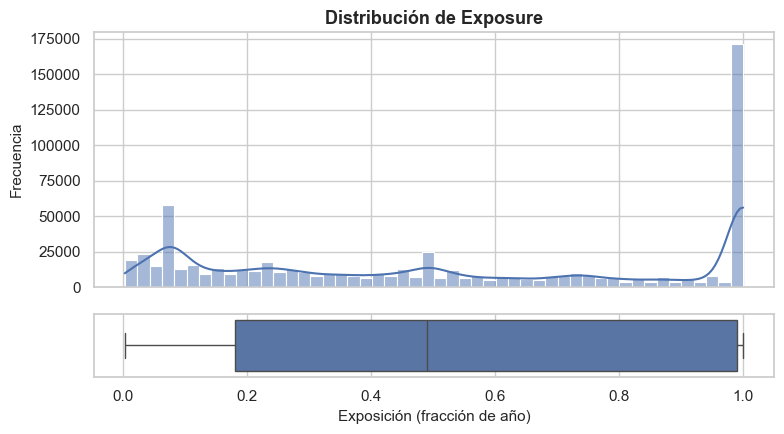

In [4]:
hist_box(df_freq["Exposure"], titulo="Distribución de Exposure",
         xlabel="Exposición (fracción de año)", bins=50, color="#4C72B0")


**Interpretación actuarial — Exposure.**
- **Rango:** la variable se mueve dentro de (0, 1], consistente con su definición como
  fracción del año durante la cual la póliza estuvo vigente y observada.
- **Significado actuarial:** `Exposure` mide el tiempo de exposición al riesgo; es el
  denominador natural de la tasa de frecuencia de siniestros (siniestros por
  año-póliza).
- **Distribución:** se observa una concentración notable de pólizas con `Exposure`
  cercano a 1 (pólizas observadas durante casi todo el año), junto con una masa
  considerable de pólizas con exposiciones parciales, lo cual es coherente con altas y
  bajas de pólizas a lo largo del período de observación.
- **Valores atípicos:** no se identifican valores fuera del rango teórico [0, 1] (ver
  también el diagnóstico de consistencia del Notebook 01).
- **Relevancia futura:** `Exposure` será central en la modelación de frecuencia, ya sea
  como *offset* en un modelo Poisson o como denominador de la tasa de siniestros a
  modelar.


#### 3.2 VehPower

In [5]:
resumen_univariado(df_freq["VehPower"], "VehPower").to_frame()

,VehPower
n,"678,007.0000"
media,6.4547
mediana,6.0000
desv_estandar,2.0509
minimo,4.0000
p1,4.0000
q1,5.0000
q3,7.0000
p99,13.0000
maximo,15.0000


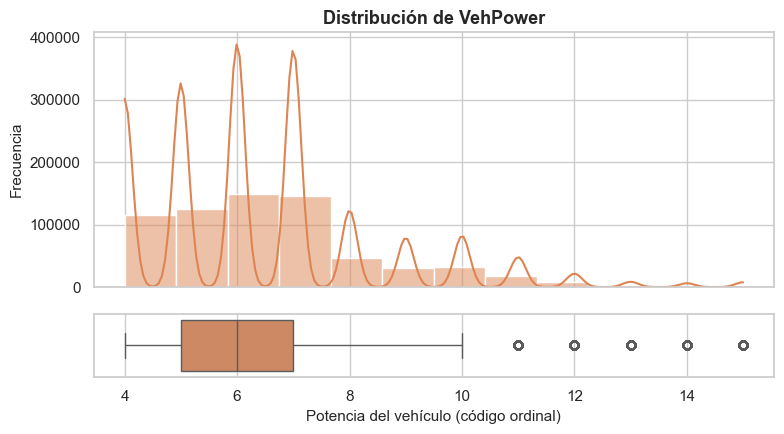

In [6]:
hist_box(df_freq["VehPower"], titulo="Distribución de VehPower",
         xlabel="Potencia del vehículo (código ordinal)", bins=12, color="#DD8452")


**Interpretación actuarial — VehPower.**
- **Rango:** la variable toma valores discretos, codificados de forma ordinal, entre el
  mínimo y el máximo observado en los datos.
- **Significado actuarial:** representa la potencia del vehículo; vehículos más
  potentes suelen asociarse, en la literatura actuarial, con un perfil de riesgo
  distinto (velocidades más altas, mayor severidad potencial).
- **Distribución:** se observa una concentración en un rango intermedio de valores,
  con menor frecuencia en los extremos (vehículos de muy baja o muy alta potencia).
- **Valores atípicos:** no se detectan valores negativos ni nulos.
- **Relevancia futura:** candidata a variable explicativa tanto para frecuencia como
  para severidad, sujeta a evaluación bivariada posterior.


#### 3.3 VehAge

In [7]:
resumen_univariado(df_freq["VehAge"], "VehAge").to_frame()

,VehAge
n,"678,007.0000"
media,7.0442
mediana,6.0000
desv_estandar,5.6662
minimo,0.0000
p1,0.0000
q1,2.0000
q3,11.0000
p99,21.0000
maximo,100.0000


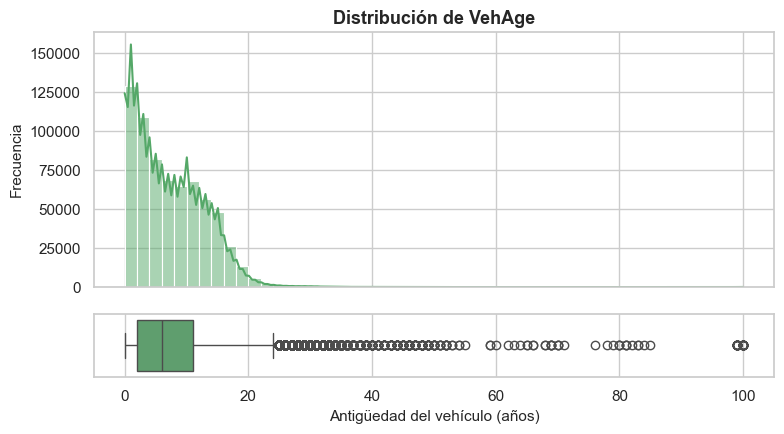

In [8]:
hist_box(df_freq["VehAge"], titulo="Distribución de VehAge",
         xlabel="Antigüedad del vehículo (años)", bins=50, color="#55A868")


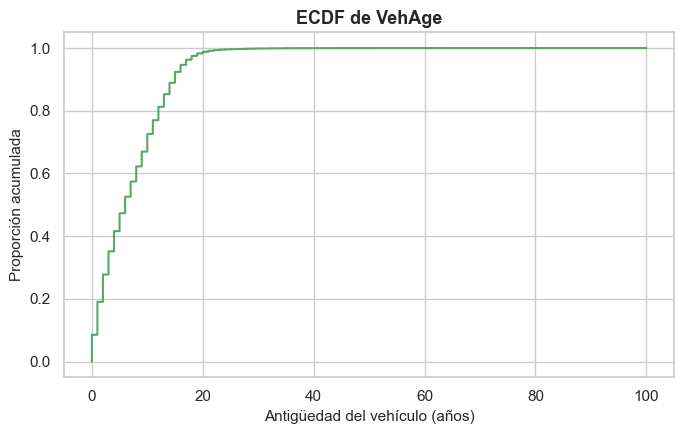

In [9]:
x, y = ecdf(df_freq["VehAge"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, y, color="#55A868")
ax.set_title("ECDF de VehAge")
ax.set_xlabel("Antigüedad del vehículo (años)")
ax.set_ylabel("Proporción acumulada")
plt.tight_layout()
plt.show()


**Interpretación actuarial — VehAge.**
- **Rango:** la variable se concentra principalmente en antigüedades bajas y
  medias, aunque el máximo observado (ver Notebook 01, Sección 12) alcanza valores
  inusualmente altos para un vehículo en circulación.
- **Significado actuarial:** la antigüedad del vehículo suele asociarse con el estado
  mecánico y con sistemas de seguridad más o menos modernos, factores potencialmente
  relevantes tanto para la frecuencia como para la severidad de los siniestros.
- **Distribución:** la ECDF muestra que la mayoría de los vehículos tiene una
  antigüedad relativamente baja, con una cola derecha larga y poco poblada.
- **Valores atípicos:** se identifican observaciones con antigüedad reportada
  extremadamente alta (ya señaladas en el diagnóstico de consistencia del Notebook 01);
  estas observaciones **no se eliminan ni se corrigen** en este notebook, y quedarán
  sujetas a revisión en la etapa de preprocesamiento.
- **Relevancia futura:** variable candidata a discretización o transformación no lineal
  en la etapa de modelación, dada su distribución asimétrica.


#### 3.4 DrivAge

In [10]:
resumen_univariado(df_freq["DrivAge"], "DrivAge").to_frame()

,DrivAge
n,"678,007.0000"
media,45.4991
mediana,44.0000
desv_estandar,14.1375
minimo,18.0000
p1,20.0000
q1,34.0000
q3,55.0000
p99,80.0000
maximo,100.0000


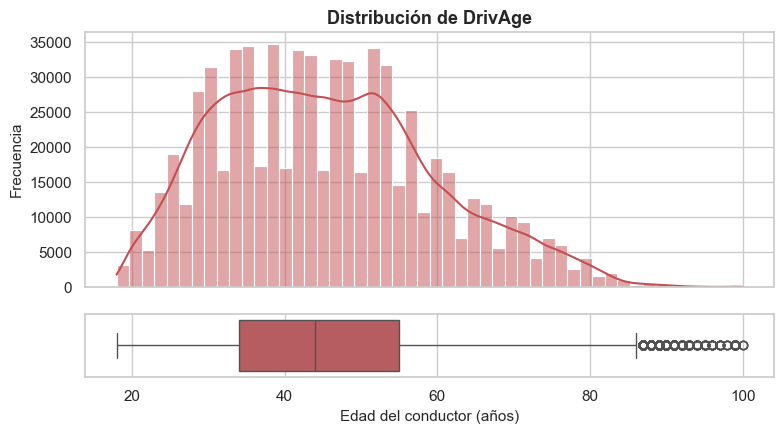

In [11]:
hist_box(df_freq["DrivAge"], titulo="Distribución de DrivAge",
         xlabel="Edad del conductor (años)", bins=50, color="#C44E52")


**Interpretación actuarial — DrivAge.**
- **Rango:** el mínimo observado es coherente con la edad legal mínima de conducción
  en Francia (18 años); el máximo, sin embargo, alcanza un valor inusualmente elevado
  (ver Notebook 01, Sección 12) que amerita revisión posterior.
- **Significado actuarial:** la edad del conductor es una de las variables de
  suscripción más utilizadas en seguros de automóviles, con una relación conocida en la
  literatura (forma de "U" o decreciente) entre edad y riesgo de siniestro.
- **Distribución:** se observa una concentración importante en edades intermedias
  (adultos de mediana edad), con menor densidad en los extremos jóvenes y de edad
  avanzada.
- **Valores atípicos:** el valor máximo reportado se documenta como un caso a revisar
  en preprocesamiento, sin asumir a priori que se trate de un error.
- **Relevancia futura:** variable de alto interés para explicar diferencias de
  frecuencia entre segmentos de conductores; su relación con `ClaimNb` se explorará en
  el análisis bivariado.


#### 3.5 BonusMalus

In [12]:
resumen_univariado(df_freq["BonusMalus"], "BonusMalus").to_frame()

,BonusMalus
n,"678,007.0000"
media,59.7616
mediana,50.0000
desv_estandar,15.6367
minimo,50.0000
p1,50.0000
q1,50.0000
q3,64.0000
p99,106.0000
maximo,230.0000


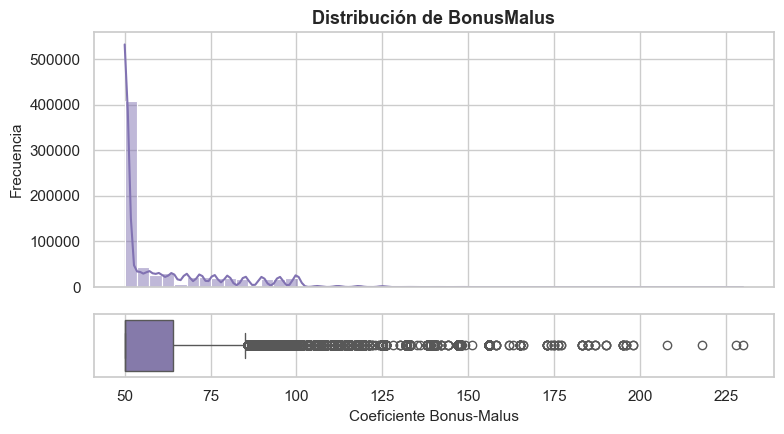

In [13]:
hist_box(df_freq["BonusMalus"], titulo="Distribución de BonusMalus",
         xlabel="Coeficiente Bonus-Malus", bins=50, color="#8172B2")


**Interpretación actuarial — BonusMalus.**
- **Rango:** los valores observados se ubican mayormente dentro del rango típico del
  sistema bonus-malus francés (50 a 350, donde 100 representa la ausencia de bonus o
  malus).
- **Significado actuarial:** este coeficiente resume el historial de siniestralidad
  previo del conductor: valores por debajo de 100 reflejan bonificaciones por buen
  historial, y valores por encima reflejan recargos por historial adverso.
- **Distribución:** se observa una concentración fuerte en el valor mínimo (bonus
  máximo, conductores sin siniestros previos), con una cola derecha hacia niveles de
  malus más altos, cada vez menos frecuentes.
- **Valores atípicos:** una minoría de pólizas se ubica en niveles de malus
  considerablemente elevados (ya cuantificados en el Notebook 01).
- **Relevancia futura:** al resumir el historial de siniestralidad, `BonusMalus` es
  una de las variables con mayor potencial explicativo esperado para la frecuencia de
  siniestros futuros, lo cual deberá confirmarse en el análisis bivariado y en la
  modelación.


#### 3.6 Density

In [14]:
resumen_univariado(df_freq["Density"], "Density").to_frame()

,Density
n,"678,007.0000"
media,"1,792.4310"
mediana,393.0000
desv_estandar,"3,958.6630"
minimo,1.0000
p1,10.0000
q1,92.0000
q3,"1,658.0000"
p99,"27,000.0000"
maximo,"27,000.0000"


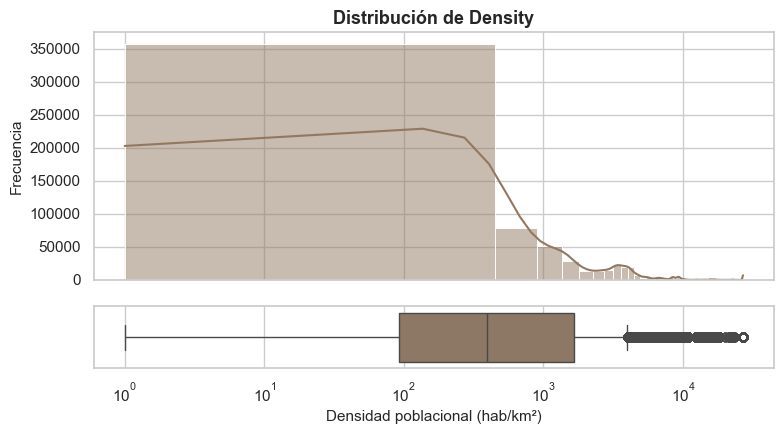

In [15]:
hist_box(df_freq["Density"], titulo="Distribución de Density",
         xlabel="Densidad poblacional (hab/km²)", bins=60, log_x=True, color="#937860")


**Interpretación actuarial — Density.**
- **Rango:** la variable abarca desde zonas muy poco pobladas hasta zonas urbanas de
  muy alta densidad, con varios órdenes de magnitud de diferencia entre el mínimo y el
  máximo.
- **Significado actuarial:** aproxima el grado de urbanización del lugar de residencia
  del conductor, un factor que en la literatura actuarial se asocia con la exposición a
  tráfico, congestión y, potencialmente, con la frecuencia de siniestros.
- **Distribución:** la distribución en escala logarítmica (utilizada aquí únicamente
  con fines de visualización) muestra una forma más simétrica que en escala original,
  lo cual confirma la fuerte asimetría positiva de la variable en su escala natural.
- **Valores atípicos:** se identifican pólizas en zonas de densidad extremadamente
  alta, cuantificadas en el diagnóstico de consistencia del Notebook 01.
- **Relevancia futura:** por su fuerte asimetría, es una variable candidata a
  transformación logarítmica en la etapa de modelación (decisión que se tomará más
  adelante, no en este notebook).


#### 3.7 ClaimNb

In [16]:
resumen_univariado(df_freq["ClaimNb"], "ClaimNb").to_frame()

,ClaimNb
n,"678,007.0000"
media,0.0389
mediana,0.0000
desv_estandar,0.2048
minimo,0.0000
p1,0.0000
q1,0.0000
q3,0.0000
p99,1.0000
maximo,5.0000


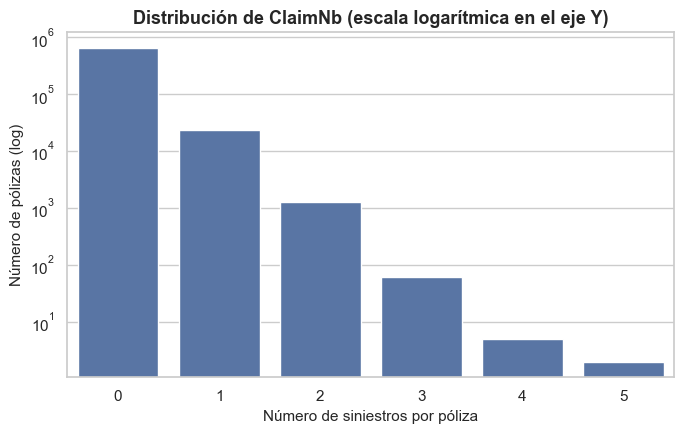

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
conteo = df_freq["ClaimNb"].value_counts().sort_index()
sns.barplot(x=conteo.index, y=conteo.values, ax=ax, color="#4C72B0")
ax.set_yscale("log")
ax.set_title("Distribución de ClaimNb (escala logarítmica en el eje Y)")
ax.set_xlabel("Número de siniestros por póliza")
ax.set_ylabel("Número de pólizas (log)")
plt.tight_layout()
plt.show()


**Interpretación actuarial — ClaimNb.**
- **Rango:** variable discreta de conteo, con un mínimo de 0 y un máximo reducido de
  siniestros observados por póliza durante el período de estudio.
- **Significado actuarial:** representa el número de siniestros de responsabilidad
  civil reportados por póliza; es la variable objetivo natural para la futura
  modelación de frecuencia.
- **Distribución:** la inmensa mayoría de las pólizas registra cero siniestros, con
  una caída muy rápida en la frecuencia de pólizas a medida que aumenta el número de
  siniestros — un patrón característico de eventos raros que sugiere distribuciones de
  conteo tipo Poisson o binomial negativa para la modelación futura.
- **Valores atípicos:** no se identifican valores negativos ni no enteros.
- **Relevancia futura:** variable objetivo central de la investigación; su relación
  con `Exposure` y con las variables de riesgo será el eje del análisis bivariado y de
  la modelación GLM/ML.


#### 3.8 ClaimAmount

In [18]:
resumen_univariado(df_sev["ClaimAmount"], "ClaimAmount").to_frame()

,ClaimAmount
n,"24,938.0000"
media,"2,397.0479"
mediana,"1,172.0000"
desv_estandar,"30,266.6188"
minimo,1.0000
p1,39.8751
q1,749.2625
q3,"1,346.3600"
p99,"17,960.2374"
maximo,"4,075,400.5600"


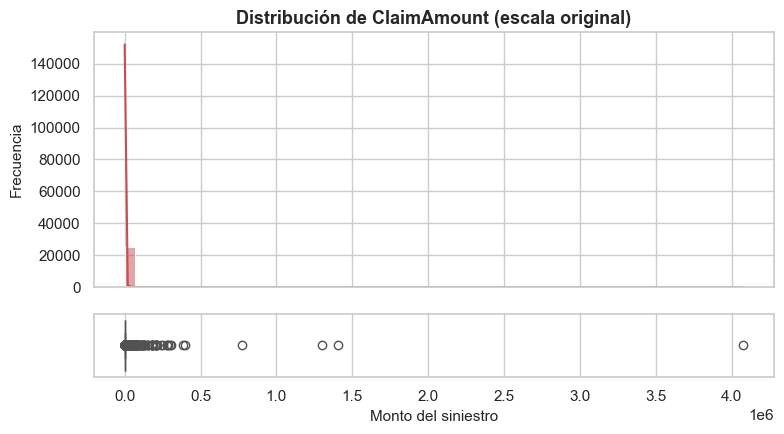

In [19]:
hist_box(df_sev["ClaimAmount"], titulo="Distribución de ClaimAmount (escala original)",
         xlabel="Monto del siniestro", bins=60, color="#C44E52")


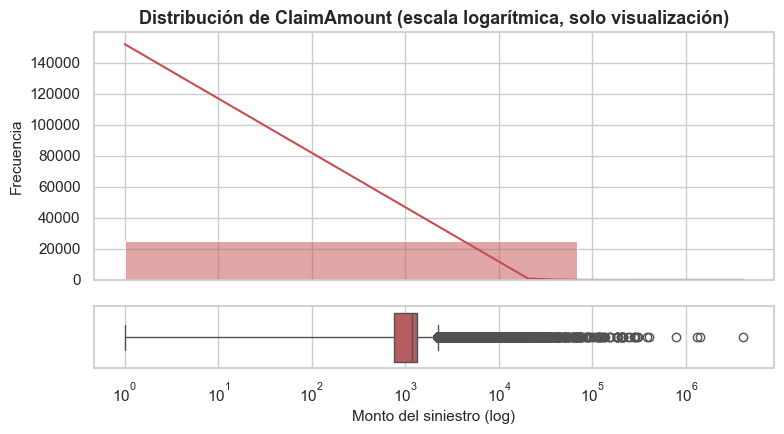

In [20]:
hist_box(df_sev["ClaimAmount"], titulo="Distribución de ClaimAmount (escala logarítmica, solo visualización)",
         xlabel="Monto del siniestro (log)", bins=60, log_x=True, color="#C44E52")


**Interpretación actuarial — ClaimAmount.**
- **Rango:** los montos van desde valores mínimos hasta siniestros excepcionalmente
  altos (ver top-10 en el Notebook 01, Sección 10), abarcando varios órdenes de
  magnitud.
- **Significado actuarial:** corresponde al monto pagado o reservado por póliza para
  los siniestros de responsabilidad civil observados; es la variable objetivo natural
  para la futura modelación de severidad.
- **Distribución:** fuertemente asimétrica a la derecha, con la mayoría de los montos
  concentrados en niveles moderados y una minoría de siniestros extremos que se alejan
  considerablemente de la media. La versión en escala logarítmica (únicamente para
  visualización) permite apreciar mejor la forma general de la distribución.
- **Valores atípicos:** los montos más altos podrían corresponder a siniestros
  genuinamente severos (relevantes de conservar) o a posibles errores de registro; esta
  distinción **no se resuelve en este notebook** y queda para la etapa de
  preprocesamiento.
- **Relevancia futura:** por su asimetría, es candidata a modelarse con distribuciones
  continuas positivas (p. ej. Gamma, Log-Normal), tal como se explorará formalmente en
  la etapa de modelación de severidad.


### 4. Variables categóricas

Se analiza, para cada variable categórica relevante de `freMTPL2freq`, el número de
categorías, la frecuencia absoluta y relativa, la categoría más frecuente y, cuando
corresponde, la menos frecuente. Para variables con muchas categorías se muestran
únicamente las principales, indicándolo explícitamente.


In [21]:
for col in ["Area", "VehGas"]:
    print(f"\n--- {col} ({df_freq[col].nunique()} categorías) ---")
    display(tabla_frecuencias(df_freq, col))



--- Area (6 categorías) ---


,frecuencia_absoluta,frecuencia_relativa_%
Area,,
C,191880,28.3000
D,151590,22.3600
E,137167,20.2300
A,103957,15.3300
B,75459,11.1300
F,17954,2.6500



--- VehGas (2 categorías) ---


,frecuencia_absoluta,frecuencia_relativa_%
VehGas,,
Regular,345871,51.0100
Diesel,332136,48.9900


**Interpretación — Area y VehGas.** `Area` (6 categorías) y `VehGas` (2
categorías) presentan baja cardinalidad, con una distribución relativamente balanceada
entre sus categorías, aunque `VehGas` muestra una ligera concentración en una de las dos
opciones (Diesel/Regular). No se observan categorías extremadamente raras.


In [22]:
print(f"VehBrand ({df_freq['VehBrand'].nunique()} categorías) — se muestran todas:")
tabla_frecuencias(df_freq, "VehBrand")


VehBrand (11 categorías) — se muestran todas:


,frecuencia_absoluta,frecuencia_relativa_%
VehBrand,,
B12,166024,24.4900
B1,162730,24.0000
B2,159861,23.5800
B3,53395,7.8800
B5,34753,5.1300
B6,28548,4.2100
B4,25179,3.7100
B10,17707,2.6100
B11,13585,2.0000


**Interpretación — VehBrand.** Las 11 categorías de marca presentan una
concentración moderada: una o dos marcas concentran una proporción relevante de las
pólizas, mientras que el resto se distribuye de forma más pareja. Esta variable podría
ser relevante como proxy de segmento de mercado o de perfil de vehículo, aunque su
relación con la siniestralidad se explorará en el análisis bivariado.


In [23]:
print(f"Region ({df_freq['Region'].nunique()} categorías) — se muestran las 10 más frecuentes (top-10):")
tabla_frecuencias(df_freq, "Region", top_n=10)


Region (22 categorías) — se muestran las 10 más frecuentes (top-10):


,frecuencia_absoluta,frecuencia_relativa_%
Region,,
R24,160601,23.6900
R82,84752,12.5000
R93,79315,11.7000
R11,69791,10.2900
R53,42122,6.2100
R52,38751,5.7200
R91,35799,5.2800
R72,31329,4.6200
R31,27285,4.0200


**Interpretación — Region.** Con 22 categorías, `Region` es la variable con
mayor cardinalidad del conjunto. Se observa una concentración de pólizas en un
subconjunto de regiones (posiblemente asociadas a mayor densidad poblacional), mientras
que otras regiones presentan una participación considerablemente menor. Esta variable
podría requerir agrupación o técnicas específicas de codificación en la etapa de
modelación, decisión que **no se toma en este notebook**.


### 5. Distribución de frecuencia

Esta sección integra, desde una perspectiva univariada, la lectura conjunta de
`ClaimNb` y `Exposure` como los dos componentes fundamentales de la frecuencia de
siniestros, sin construir todavía ninguna tasa modelada.


In [24]:
print("Resumen conjunto de las variables de frecuencia:")
display(pd.DataFrame({
    "ClaimNb": resumen_univariado(df_freq["ClaimNb"], "ClaimNb"),
    "Exposure": resumen_univariado(df_freq["Exposure"], "Exposure"),
}))


Resumen conjunto de las variables de frecuencia:


,ClaimNb,Exposure
n,"678,007.0000","678,007.0000"
media,0.0389,0.5285
mediana,0.0000,0.4900
desv_estandar,0.2048,0.3641
minimo,0.0000,0.0027
p1,0.0000,0.0082
q1,0.0000,0.1800
q3,0.0000,0.9900
p99,1.0000,1.0000
maximo,5.0000,1.0000


**Interpretación.** `ClaimNb` es una variable de conteo dominada por el valor
cero, mientras que `Exposure` es una variable continua acotada en (0, 1]. Ambas, en
conjunto, describen por completo el fenómeno de frecuencia a nivel de póliza: cuántos
siniestros ocurrieron y durante cuánto tiempo estuvo la póliza expuesta al riesgo. Esta
relación es la base conceptual —aunque no se modela aquí— de la tasa de frecuencia que
se abordará formalmente en etapas posteriores de la investigación.


### 6. Distribución de severidad

Se retoma, desde la perspectiva univariada, la variable `ClaimAmount` como
representación del costo de los siniestros.


In [25]:
resumen_univariado(df_sev["ClaimAmount"], "ClaimAmount").to_frame()

,ClaimAmount
n,"24,938.0000"
media,"2,397.0479"
mediana,"1,172.0000"
desv_estandar,"30,266.6188"
minimo,1.0000
p1,39.8751
q1,749.2625
q3,"1,346.3600"
p99,"17,960.2374"
maximo,"4,075,400.5600"


**Interpretación.** Como se documentó en la Sección 3.8, `ClaimAmount` presenta
una distribución con asimetría positiva marcada. Desde la perspectiva actuarial, esto
implica que la media aritmética por sí sola puede no ser representativa del "siniestro
típico"; medidas robustas como la mediana, junto con los percentiles altos, ofrecen una
lectura más completa del riesgo de cola presente en la severidad.


### 7. Identificación descriptiva de valores extremos

Se cuantifican, de forma puramente descriptiva, las observaciones que se ubican fuera
del rango intercuartílico extendido (regla de 1.5×RIC) para las principales variables
numéricas. **No se eliminan ni se corrigen observaciones**: esta sección únicamente
documenta la magnitud del fenómeno para informar la futura etapa de preprocesamiento.


In [26]:
def contar_atipicos_iqr(serie, k=1.5):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - k * iqr, q3 + k * iqr
    n_atipicos = int(((serie < limite_inf) | (serie > limite_sup)).sum())
    return pd.Series({
        "limite_inferior": limite_inf,
        "limite_superior": limite_sup,
        "n_atipicos_iqr": n_atipicos,
        "%_atipicos": round(n_atipicos / len(serie) * 100, 3),
    })

variables_a_revisar = {
    "VehAge": df_freq["VehAge"],
    "DrivAge": df_freq["DrivAge"],
    "BonusMalus": df_freq["BonusMalus"],
    "Density": df_freq["Density"],
    "ClaimAmount": df_sev["ClaimAmount"],
}

pd.DataFrame({nombre: contar_atipicos_iqr(serie) for nombre, serie in variables_a_revisar.items()}).T


,limite_inferior,limite_superior,n_atipicos_iqr,%_atipicos
VehAge,-11.5000,24.5000,"3,114.0000",0.4590
DrivAge,2.5000,86.5000,"1,275.0000",0.1880
BonusMalus,29.0000,85.0000,"62,384.0000",9.2010
Density,"-2,257.0000","4,007.0000","77,566.0000",11.4400
ClaimAmount,-146.3838,"2,242.0063","3,754.0000",15.0530


**Interpretación.** La regla de 1.5×RIC identifica, como es esperable dado su
naturaleza altamente asimétrica, una proporción no despreciable de observaciones
"atípicas" en `Density` y `ClaimAmount`; esto es consistente con distribuciones de cola
pesada y **no implica automáticamente que se trate de errores de datos**. En
`VehAge`, `DrivAge` y `BonusMalus` la proporción de atípicos según esta regla es menor,
aunque coherente con los valores extremos ya señalados en el diagnóstico de consistencia
del Notebook 01. La decisión sobre cómo tratar estas observaciones (conservarlas,
transformarlas o acotarlas) se tomará explícitamente en la etapa de preprocesamiento,
con criterios actuariales y estadísticos adicionales.


### 8. Hallazgos principales

1. Las variables numéricas de riesgo (`VehPower`, `VehAge`, `DrivAge`, `BonusMalus`,
   `Density`) presentan formas de distribución heterogéneas: desde relativamente
   simétricas (`VehPower`) hasta fuertemente asimétricas (`Density`).
2. `Exposure` se comporta como variable acotada en (0, 1], sin valores fuera de rango.
3. `ClaimNb` confirma su naturaleza de variable de conteo dominada por ceros, propia de
   eventos raros en seguros de automóviles.
4. `ClaimAmount` exhibe una asimetría positiva marcada, con una cola derecha pesada que
   concentra una proporción relevante del costo total de siniestros.
5. Las variables categóricas (`Area`, `VehGas`, `VehBrand`, `Region`) presentan
   cardinalidades manejables, con distintos grados de concentración en sus categorías
   dominantes.
6. La identificación descriptiva de valores extremos confirma, de forma cuantitativa,
   los hallazgos cualitativos del Notebook 01 respecto a `VehAge`, `DrivAge`, `Density`
   y `ClaimAmount`.

### 9. Conclusiones

El análisis univariado permite caracterizar, variable por variable, el comportamiento
individual de los datos `freMTPL2`, sin necesidad todavía de establecer relaciones entre
variables ni de construir modelos predictivos. Esta caracterización constituye una base
sólida para las siguientes etapas de la investigación: el análisis bivariado y
multivariado (que explorará relaciones entre las variables de riesgo y la
siniestralidad), el preprocesamiento formal de los datos (que abordará los valores
atípicos y las particularidades documentadas aquí y en el Notebook 01), y finalmente la
construcción y comparación de los modelos de frecuencia, severidad y prima pura
mediante GLM, algoritmos de Machine Learning y redes neuronales — etapas que quedan
explícitamente fuera del alcance de este notebook.
